In [37]:
# Importação de bibliotecas e configuração inicial
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, applications, callbacks
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.utils import resample
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import cv2 # Para redimensionamento das imagens
import optuna

# Configuração de semente para reprodutibilidade
tf.random.set_seed(42)
np.random.seed(42)

In [38]:
# 1. Carregar os dados empacotados anteriormente
data = np.load('/kaggle/input/datasets/lscolombo/hwu-usp-for-rp/hwu_usp_for_rp.npz')

X_train_raw = data['X_train']
y_train = data['y_train']
X_val_raw = data['X_val']
y_val = data['y_val']
X_test_raw = data['X_test']
y_test = data['y_test']

print(f"Formato original de X_train: {X_train_raw.shape}")

# 2. Mapeamento das colunas
# - Índices 0 e 12: timesteps (para descartar)
# - Índices 1 a 11 (11 features): Sensores ambientais (PIR, magnéticos, etc.)
# - Índices 13 a 24 (12 features): Sensores inerciais (Acelerômetro/Giroscópio de cintura e pulso)

idx_timesteps = [0, 12]
idx_ambientais = list(range(1, 12)) # Pega do índice 1 até o 11
idx_inerciais = list(range(13, 25)) # Pega do índice 13 até o 24

# 3. Fatiamento (Slicing) dos arrays
X_train_inercial = X_train_raw[:, :, idx_inerciais]
X_train_ambiental = X_train_raw[:, :, idx_ambientais]

X_val_inercial = X_val_raw[:, :, idx_inerciais]
X_val_ambiental = X_val_raw[:, :, idx_ambientais]

X_test_inercial = X_test_raw[:, :, idx_inerciais]
X_test_ambiental = X_test_raw[:, :, idx_ambientais]

print(f"X_train_inercial: {X_train_inercial.shape} | X_train_ambiental: {X_train_ambiental.shape}")
print(f"X_val_inercial: {X_val_inercial.shape} | X_val_ambiental: {X_val_ambiental.shape}")


Formato original de X_train: (2676, 125, 25)
X_train_inercial: (2676, 125, 12) | X_train_ambiental: (2676, 125, 11)
X_val_inercial: (601, 125, 12) | X_val_ambiental: (601, 125, 11)


In [39]:
# CÉLULA 3
import cv2
from scipy.spatial.distance import pdist, squareform

class URP_DataGenerator(tf.keras.utils.Sequence):
    def __init__(self, X_inercial, X_ambiental, y_labels, batch_size=32, target_size=(112, 112), shuffle=True, global_max_dist=5.0, **kwargs):
        super().__init__(**kwargs)
        self.X_inercial = X_inercial
        self.X_ambiental = X_ambiental
        self.y_labels = y_labels
        self.batch_size = batch_size
        self.target_size = target_size
        self.shuffle = shuffle

        # Define o máximo global para normalizar mantendo a amplitude do movimento
        self.global_max_dist = global_max_dist

        self.indexes = np.arange(len(self.X_inercial))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __len__(self):
        # Usa np.ceil para incluir o último lote, mesmo que seja menor que o batch_size
        return int(np.ceil(len(self.X_inercial) / float(self.batch_size)))

    def __getitem__(self, index):
        indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]

        batch_X_inercial = self.X_inercial[indexes]
        batch_X_ambiental = self.X_ambiental[indexes]
        batch_y = self.y_labels[indexes]

        # Tamanho real deste lote (importante para o último lote da época)
        current_batch_size = len(indexes)
        batch_img = np.zeros((current_batch_size, self.target_size[0], self.target_size[1], 3), dtype=np.float32)

        for i in range(current_batch_size):
            window = batch_X_inercial[i]

            # Separação dos eixos espaciais para formar o RGB (X = R, Y = G, Z = B)
            indices_R = [0, 3, 6, 9]
            indices_G = [1, 4, 7, 10]
            indices_B = [2, 5, 8, 11]

            eixos = [indices_R, indices_G, indices_B]

            # Gerar a URP para cada canal (RGB)
            for c, idxs in enumerate(eixos):
                # Calcula a matriz de distância
                dist_matrix = squareform(pdist(window[:, idxs], metric='euclidean'))

                # Normalização global corrigida (Clip entre 0.0 e 1.0)
                dist_matrix = np.clip(dist_matrix / self.global_max_dist, 0.0, 1.0)

                # Redimensiona e aloca no canal correto
                dist_matrix_resized = cv2.resize(dist_matrix, self.target_size, interpolation=cv2.INTER_LINEAR)
                batch_img[i, :, :, c] = dist_matrix_resized

        return (batch_img, batch_X_ambiental), batch_y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

print("Instanciando os Geradores de Dados...")

train_generator = URP_DataGenerator(X_train_inercial, X_train_ambiental, y_train, batch_size=32)
val_generator = URP_DataGenerator(X_val_inercial, X_val_ambiental, y_val, batch_size=32, shuffle=False)
test_generator = URP_DataGenerator(X_test_inercial, X_test_ambiental, y_test, batch_size=32, shuffle=False)

print("Geradores prontos para alimentar a rede!")

Instanciando os Geradores de Dados...
Geradores prontos para alimentar a rede!


In [40]:
def build_hybrid_model(img_shape, env_shape, num_classes):
    # ---------------------------------------------------------
    # RAMO 1: Visão Computacional (ResNet-50 para Sensores Inerciais)
    # ---------------------------------------------------------
    input_img = layers.Input(shape=img_shape, name='input_imagem_urp')

    # Carregando a ResNet50
    x_img = tf.keras.applications.resnet50.preprocess_input(input_img * 255.0)
    base_resnet = applications.ResNet50(weights='imagenet', include_top=False, input_tensor=x_img)

    # Congelar as camadas iniciais da ResNet para agilizar o treino e evitar esquecimento catastrófico
    for layer in base_resnet.layers[:-15]:
        layer.trainable = False

    x_img = base_resnet.output
    x_img = layers.GlobalAveragePooling2D()(x_img)
    x_img = layers.Dense(128, activation='relu')(x_img)
    x_img = layers.Dropout(0.3)(x_img)

    # ---------------------------------------------------------
    # RAMO 2: CNN 1D (Para Sensores Ambientais/Binários)
    # ---------------------------------------------------------
    input_env = layers.Input(shape=env_shape, name='input_ambiental')

    x_env = layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(input_env)
    x_env = layers.MaxPooling1D(pool_size=2)(x_env)
    x_env = layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(x_env)
    x_env = layers.GlobalAveragePooling1D()(x_env)
    x_env = layers.Dense(64, activation='relu')(x_env)

    # ---------------------------------------------------------
    # FUSÃO (Concatenation)
    # ---------------------------------------------------------
    merged = layers.concatenate([x_img, x_env])

    # Camadas finais de classificação
    z = layers.Dense(64, activation='relu')(merged)
    z = layers.Dropout(0.2)(z)
    output = layers.Dense(num_classes, activation='softmax', name='saida_classificacao')(z)

    # Compilação do Modelo
    model = models.Model(inputs=[input_img, input_env], outputs=output)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss='sparse_categorical_crossentropy', # Use 'categorical_crossentropy' se o y estiver em One-Hot
        metrics=['accuracy']
    )

    return model

# Parâmetros
IMG_SHAPE = (112, 112, 3)
ENV_SHAPE = (125, 11) # (tamanho_janela, num_features_ambientais)
NUM_CLASSES = len(np.unique(y_train))

model = build_hybrid_model(IMG_SHAPE, ENV_SHAPE, NUM_CLASSES)
model.summary()

Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_imagem_urp    │ (None, 112, 112,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_14         │ (None, 112, 112,  │          0 │ input_imagem_urp… │
│ (Multiply)          │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_42         │ (None, 112, 112)  │          0 │ multiply_14[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_43         │ (None, 112, 112)  │          0 │ multiply_14[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_44         │ (None, 112, 112)  │          0 │ multiply_14[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_14 (Stack)    │ (None, 112, 112,  │          0 │ get_item_42[0][0… │
│                     │ 3)                │            │ get_item_43[0][0… │
│                     │                   │            │ get_item_44[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_14 (Add)        │ (None, 112, 112,  │          0 │ stack_14[0][0]    │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 118, 118,  │          0 │ add_14[0][0]      │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 56, 56,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 56, 56,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 56, 56,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 58, 58,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 28, 28,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 28, 28,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 28, 28,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 28, 28,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 23,874,377 (91.07 MB)

 Trainable params: 5,807,049 (22.15 MB)

 Non-trainable params: 18,067,328 (68.92 MB)

In [41]:
# CÉLULA 5 - SUBSTITUA PELA VERSÃO CORRIGIDA PARA KERAS 3
callbacks_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    callbacks.ModelCheckpoint('melhor_modelo_hibrido_urp.keras', monitor='val_accuracy', save_best_only=True)
]

# Início do treinamento usando os Geradores Otimizados
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=callbacks_list
)

Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 34s 219ms/step - accuracy: 0.2221 - loss: 3.2530 - val_accuracy: 0.3428 - val_loss: 1.8472
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.3608 - loss: 1.7319 - val_accuracy: 0.3178 - val_loss: 1.9193
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.4214 - loss: 1.6080 - val_accuracy: 0.3411 - val_loss: 2.1071
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.4875 - loss: 1.4339 - val_accuracy: 0.4110 - val_loss: 1.8528
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.5313 - loss: 1.3175 - val_accuracy: 0.3644 - val_loss: 1.8491
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.5980 - loss: 1.1529 - val_accuracy: 0.3644 - val_loss: 2.0460
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.6585 - loss: 0.9994 - val_accuracy: 0.3677 - val_loss: 2.2380
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.7289 - loss: 0.8042 - val_accuracy: 0.3877 -

60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.2740 - loss: 2.7275
Acurácia no Teste: 0.2718
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.18      0.32      0.23       213
           1       0.17      0.38      0.23       159
           2       0.45      0.46      0.46       197
           3       0.29      0.19      0.23       262
           4       0.23      0.21      0.22       208
           5       0.49      0.42      0.45       234
           6       0.00      0.00      0.00        77
           7       0.27      0.27      0.27       256
           8       0.26      0.12      0.17       289

    accuracy                           0.27      1895
   macro avg       0.26      0.26      0.25      1895
weighted avg       0.28      0.27      0.27      1895



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


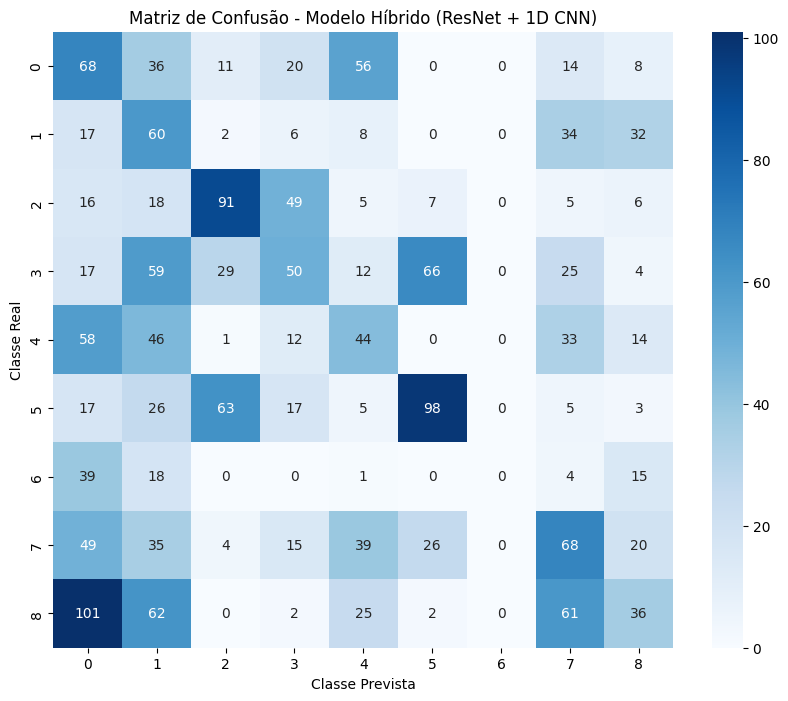

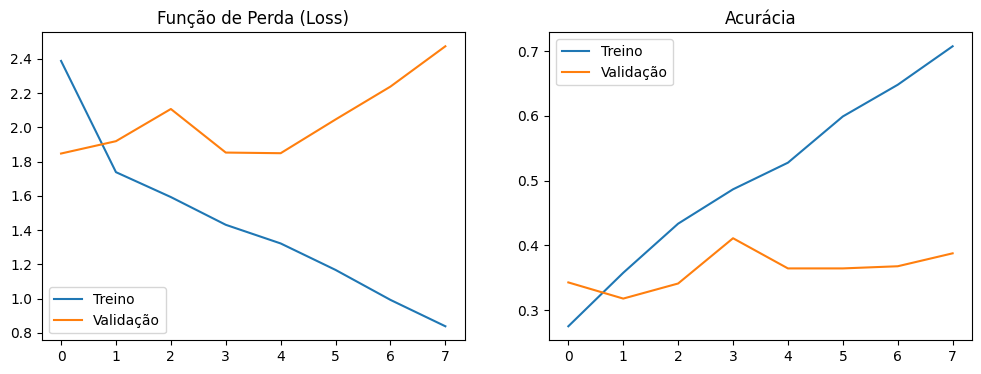

In [42]:
# Avaliação geral no conjunto de Teste
test_loss, test_acc = model.evaluate(test_generator)
print(f"Acurácia no Teste: {test_acc:.4f}")

# Previsões para as métricas detalhadas
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# Relatório de Classificação (F1-score, Precision, Recall por atividade)
print("\nRelatório de Classificação:")
# Agora podemos usar o y_test original completo
print(classification_report(y_test, y_pred))

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusão - Modelo Híbrido (ResNet + 1D CNN)")
plt.ylabel('Classe Real')
plt.xlabel('Classe Prevista')
plt.show()

# Curvas de Aprendizado
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Função de Perda (Loss)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Acurácia')
plt.legend()
plt.show()

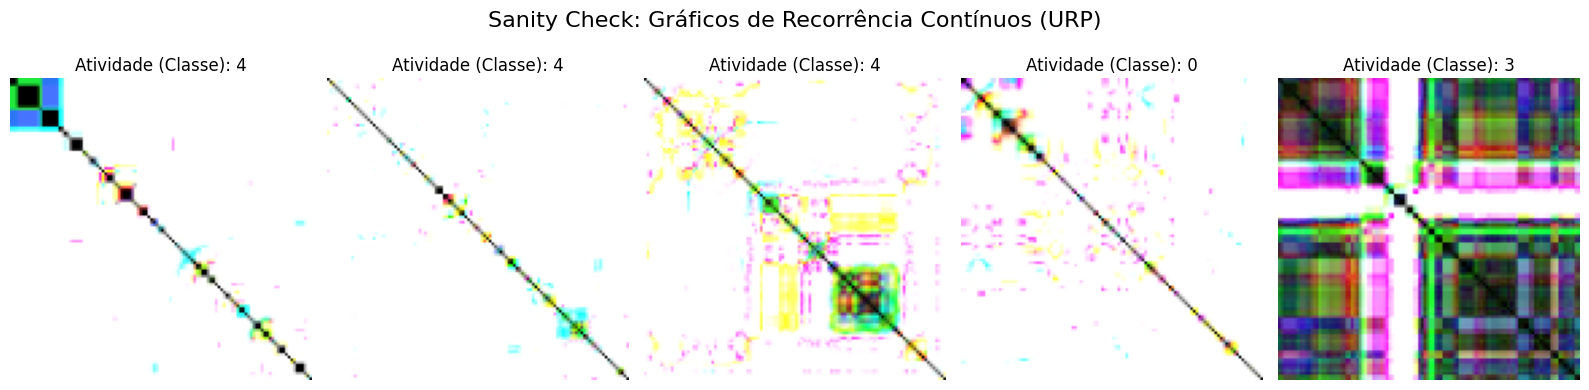

In [43]:
import matplotlib.pyplot as plt

# 1. Extrair o primeiro lote (batch) do gerador de treino
# O gerador devolve: (Input_Imagens, Input_Ambiental), Labels
(X_img_batch, X_env_batch), y_batch = train_generator[0]

# 2. Definir quantas imagens queremos visualizar lado a lado
num_imagens = 5

plt.figure(figsize=(16, 4))

for i in range(num_imagens):
    plt.subplot(1, num_imagens, i + 1)

    # Extrair a imagem individual do lote
    # A imagem tem formato (112, 112, 3) e valores entre 0.0 e 1.0,
    # o que é perfeito para o plt.imshow()
    img = X_img_batch[i]

    plt.imshow(img)
    plt.title(f"Atividade (Classe): {y_batch[i]}")
    plt.axis('off') # Remove os eixos para uma visualização mais limpa

plt.tight_layout()
plt.suptitle("Sanity Check: Gráficos de Recorrência Contínuos (URP)", fontsize=16, y=1.05)
plt.show()

## Experimento 1: Treinamento com Balanceamento de Classes (Class Weights)
Nesta etapa, calculamos os pesos inversamente proporcionais à frequência de cada classe. Isso ajuda o modelo a não ignorar atividades raras.

In [44]:
from sklearn.utils.class_weight import compute_class_weight

# 1. Calcular os pesos das classes com base no y_train
classes_unicas = np.unique(y_train)
pesos = compute_class_weight(class_weight='balanced', classes=classes_unicas, y=y_train)
class_weights_dict = {cls: weight for cls, weight in zip(classes_unicas, pesos)}

print("Pesos calculados para cada classe:")
for cls, w in class_weights_dict.items():
    print(f"Classe {cls}: {w:.4f}")

# 2. Recriar o modelo para garantir que os pesos iniciem do zero (sem viés do treino anterior)
model_exp1 = build_hybrid_model(IMG_SHAPE, ENV_SHAPE, NUM_CLASSES)

callbacks_exp1 = [
    callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    callbacks.ModelCheckpoint('modelo_exp1_balanced.keras', monitor='val_accuracy', save_best_only=True)
]

# 3. Treinar usando class_weight e Paralelismo
print("\nIniciando Experimento 1...")
history_exp1 = model_exp1.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=callbacks_exp1,
    class_weight=class_weights_dict
)

Pesos calculados para cada classe:
Classe 0: 0.7566
Classe 1: 1.0972
Classe 2: 1.0544
Classe 3: 1.0581
Classe 4: 0.8643
Classe 5: 1.3098
Classe 6: 1.7187
Classe 7: 0.7845
Classe 8: 0.9121

Iniciando Experimento 1...
Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 33s 216ms/step - accuracy: 0.2407 - loss: 2.4436 - val_accuracy: 0.2612 - val_loss: 1.9607
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.3429 - loss: 1.6991 - val_accuracy: 0.3710 - val_loss: 1.8087
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.4530 - loss: 1.4979 - val_accuracy: 0.3611 - val_loss: 1.9125
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.5190 - loss: 1.2970 - val_accuracy: 0.3860 - val_loss: 1.7908
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.5601 - loss: 1.1851 - val_accuracy: 0.3810 - val_loss: 1.8085
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.6078 - loss: 1.0420 - val_accuracy: 0.3211 - val_loss: 3.1648
Epoch 7/50
84/84 ━━━

## Experimento 2: Otimização de Hiperparâmetros com Optuna
Aqui vamos buscar automaticamente a melhor combinação de hiperparâmetros (Learning Rate, Unidades Densas e Dropout).

In [45]:
!pip install optuna

In [46]:
import optuna

def build_optuna_model(trial):
    # --- Espaço de Busca (Search Space) ---
    lr = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)
    dense_img = trial.suggest_categorical("dense_img", [64, 128, 256])
    dropout_img = trial.suggest_float("dropout_img", 0.2, 0.5)

    filters_1d_1 = trial.suggest_categorical("filters_1d_1", [16, 32, 64])
    dense_env = trial.suggest_categorical("dense_env", [32, 64, 128])

    dense_final = trial.suggest_categorical("dense_final", [32, 64, 128])
    dropout_final = trial.suggest_float("dropout_final", 0.2, 0.5)

    # --- RAMO 1: Visão Computacional (ResNet-50) ---
    input_img = layers.Input(shape=IMG_SHAPE, name='input_imagem_urp')
    x_img = tf.keras.applications.resnet50.preprocess_input(input_img * 255.0)
    base_resnet = applications.ResNet50(weights='imagenet', include_top=False, input_tensor=x_img)

    for layer in base_resnet.layers[:-15]:
        layer.trainable = False

    x_img = base_resnet.output
    x_img = layers.GlobalAveragePooling2D()(x_img)
    x_img = layers.Dense(dense_img, activation='relu')(x_img)
    x_img = layers.Dropout(dropout_img)(x_img)

    # --- RAMO 2: CNN 1D (Ambientais) ---
    input_env = layers.Input(shape=ENV_SHAPE, name='input_ambiental')
    x_env = layers.Conv1D(filters=filters_1d_1, kernel_size=3, activation='relu', padding='same')(input_env)
    x_env = layers.MaxPooling1D(pool_size=2)(x_env)
    x_env = layers.Conv1D(filters=filters_1d_1*2, kernel_size=3, activation='relu', padding='same')(x_env)
    x_env = layers.GlobalAveragePooling1D()(x_env)
    x_env = layers.Dense(dense_env, activation='relu')(x_env)

    # --- FUSÃO ---
    merged = layers.concatenate([x_img, x_env])
    z = layers.Dense(dense_final, activation='relu')(merged)
    z = layers.Dropout(dropout_final)(z)
    output = layers.Dense(NUM_CLASSES, activation='softmax')(z)

    model_opt = models.Model(inputs=[input_img, input_env], outputs=output)
    model_opt.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model_opt

def objective(trial):
    model_opt = build_optuna_model(trial)

    # Treinamento curto para avaliar rapidamente cada tentativa
    early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    history_opt = model_opt.fit(
        train_generator,
        validation_data=val_generator,
        epochs=10, # Usamos menos épocas para o Optuna rodar em tempo razoável
        callbacks=[early_stop],
        class_weight=class_weights_dict, # Mantemos o balanceamento no Optuna também
        verbose=0 # Oculta logs massivos de treino
    )

    val_acc = max(history_opt.history['val_accuracy'])
    return val_acc

print("Iniciando Optuna...")
study = optuna.create_study(direction="maximize")
# Executando 5 tentativas de busca (aumente n_trials se tiver mais tempo e GPU disponível)
study.optimize(objective, n_trials=5)

print("\n--- Melhor Configuração Encontrada ---")
best_trial = study.best_trial
print(f"Acurácia de Validação: {best_trial.value:.4f}")
print("Hiperparâmetros:")
for key, value in best_trial.params.items():
    print(f"  {key}: {value}")

[I 2026-04-24 21:04:55,568] A new study created in memory with name: no-name-f3ca5ca8-618c-4d0d-b8e7-78a80c62a392


Iniciando Optuna...


[I 2026-04-24 21:05:54,574] Trial 0 finished with value: 0.40599000453948975 and parameters: {'learning_rate': 0.00041176476326750954, 'dense_img': 128, 'dropout_img': 0.2534638814203592, 'filters_1d_1': 32, 'dense_env': 128, 'dense_final': 32, 'dropout_final': 0.3343049039577584}. Best is trial 0 with value: 0.40599000453948975.
[I 2026-04-24 21:07:03,753] Trial 1 finished with value: 0.4226289391517639 and parameters: {'learning_rate': 2.18830743129238e-05, 'dense_img': 64, 'dropout_img': 0.36953046521530886, 'filters_1d_1': 16, 'dense_env': 32, 'dense_final': 64, 'dropout_final': 0.28734803346002835}. Best is trial 1 with value: 0.4226289391517639.
[I 2026-04-24 21:08:07,658] Trial 2 finished with value: 0.4193011522293091 and parameters: {'learning_rate': 0.00036172581661928437, 'dense_img': 128, 'dropout_img': 0.4097926047494613, 'filters_1d_1': 64, 'dense_env': 32, 'dense_final': 64, 'dropout_final': 0.4298905041456791}. Best is trial 1 with value: 0.4226289391517639.
[I 2026-04-


--- Melhor Configuração Encontrada ---
Acurácia de Validação: 0.4226
Hiperparâmetros:
  learning_rate: 2.18830743129238e-05
  dense_img: 64
  dropout_img: 0.36953046521530886
  filters_1d_1: 16
  dense_env: 32
  dense_final: 64
  dropout_final: 0.28734803346002835


## Avaliação de Resultados (Bootstrap, Curvas, Matriz de Confusão e URPs)
Função auxiliar para padronizar a saída de cada experimento.

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.utils import resample
import cv2
from scipy.spatial.distance import pdist, squareform

def plot_urps_for_classes(X_inercial, y_labels, global_max_dist=5.0, target_size=(112, 112)):
    """Extrai uma amostra de cada classe do conjunto de teste e plota a URP correspondente."""
    classes = np.unique(y_labels)
    num_classes = len(classes)

    # Ajusta o tamanho da figura dinamicamente dependendo de quantas classes existem
    cols = min(5, num_classes)
    rows = (num_classes - 1) // cols + 1
    plt.figure(figsize=(3 * cols, 3 * rows))

    for idx, cls in enumerate(classes):
        # Encontrar o índice da primeira instância que pertence a esta classe
        inst_idx = np.where(y_labels == cls)[0][0]
        window = X_inercial[inst_idx]

        img = np.zeros((target_size[0], target_size[1], 3), dtype=np.float32)

        indices_R = [0, 3, 6, 9]
        indices_G = [1, 4, 7, 10]
        indices_B = [2, 5, 8, 11]
        eixos = [indices_R, indices_G, indices_B]

        for c, e_idxs in enumerate(eixos):
            dist_matrix = squareform(pdist(window[:, e_idxs], metric='euclidean'))
            dist_matrix = np.clip(dist_matrix / global_max_dist, 0.0, 1.0)
            img[:, :, c] = cv2.resize(dist_matrix, target_size, interpolation=cv2.INTER_LINEAR)

        plt.subplot(rows, cols, idx + 1)
        plt.imshow(img)
        plt.title(f"Classe {cls}")
        plt.axis('off')

    plt.suptitle("Recurrence Plots (URP) - 1 Instância por Classe", fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

def evaluate_experiment(model, history, test_gen, y_true, X_test_in, exp_name, n_iterations=1000):
    print(f"\n{'='*20} RESULTADOS: {exp_name} {'='*20}")

    # 1. Previsões no conjunto de teste
    print("\nFazendo previsões...")
    y_pred_probs = model.predict(test_gen)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # 2. Bootstrap (Acurácia e F1-Score)
    print(f"Calculando métricas com Bootstrap ({n_iterations} iterações)...")
    acc_scores = []
    f1_scores = []
    for _ in range(n_iterations):
        # Realiza amostragem com reposição (resampling)
        indices = resample(np.arange(len(y_pred)), replace=True)
        acc_scores.append(accuracy_score(y_true[indices], y_pred[indices]))
        f1_scores.append(f1_score(y_true[indices], y_pred[indices], average='macro'))

    print(f"\n[BOOTSTRAP] Acurácia Média: {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}")
    print(f"[BOOTSTRAP] F1-Score Macro Médio: {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}\n")

    # 3. Relatório de Classificação
    print("Relatório de Classificação:")
    print(classification_report(y_true, y_pred))

    # 4. Matriz de Confusão
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Matriz de Confusão - {exp_name}")
    plt.ylabel('Classe Real')
    plt.xlabel('Classe Prevista')
    plt.show()

    # 5. Curvas de Aprendizado
    if history:
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        plt.plot(history.history['loss'], label='Treino Loss')
        plt.plot(history.history['val_loss'], label='Validação Loss')
        plt.title('Curva de Aprendizado - Função de Perda')
        plt.xlabel('Épocas')
        plt.ylabel('Loss')
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(history.history['accuracy'], label='Treino Acc')
        plt.plot(history.history['val_accuracy'], label='Validação Acc')
        plt.title('Curva de Aprendizado - Acurácia')
        plt.xlabel('Épocas')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.show()

    # 6. Gráficos URP
    plot_urps_for_classes(X_test_in, y_true)
    print(f"{'='*60}\n")

### Executando Avaliação para o Experimento 1


==================== RESULTADOS: Experimento 1 (Balanced Class Weights) ====================

Fazendo previsões...
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step
Calculando métricas com Bootstrap (1000 iterações)...

[BOOTSTRAP] Acurácia Média: 0.3472 ± 0.0110
[BOOTSTRAP] F1-Score Macro Médio: 0.3299 ± 0.0103

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.21      0.10      0.13       213
           1       0.20      0.36      0.26       159
           2       0.56      0.55      0.55       197
           3       0.45      0.50      0.47       262
           4       0.15      0.11      0.12       208
           5       0.58      0.47      0.52       234
           6       0.18      0.38      0.24        77
           7       0.42      0.27      0.33       256
           8       0.30      0.38      0.34       289

    accuracy                           0.35      1895
   macro avg       0.34      0.35      0.33      1895
weighted avg   

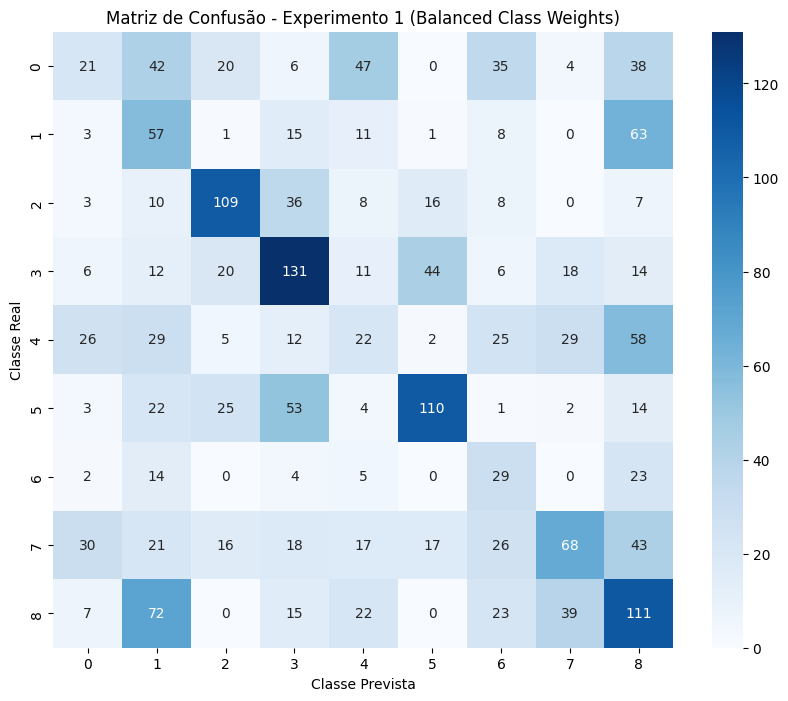

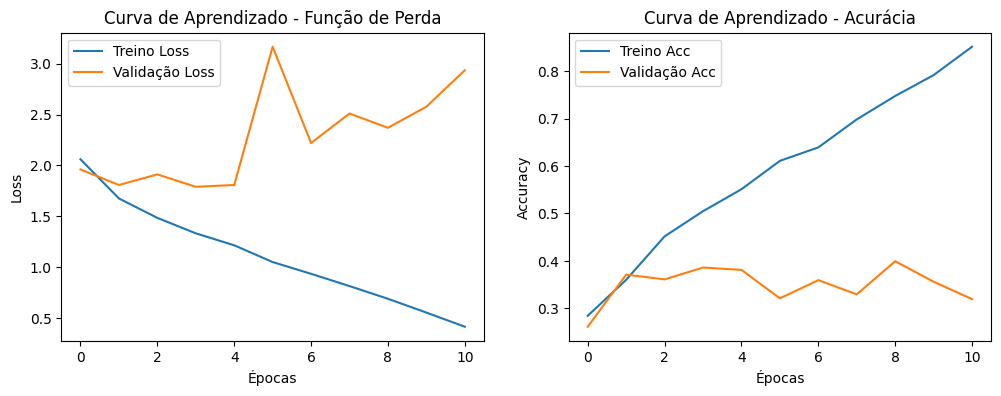

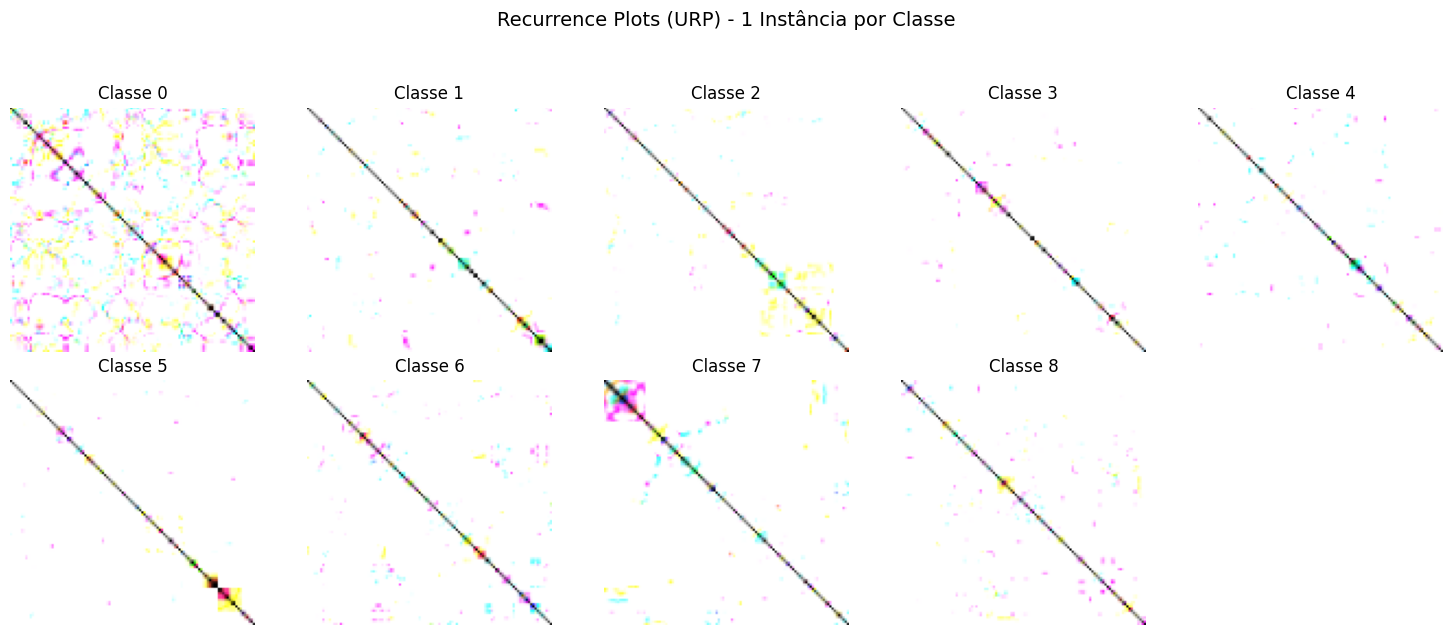

In [48]:
# Avaliação Exp 1 (Modelo balanceado sem otimização extra)
evaluate_experiment(model_exp1, history_exp1, test_generator, y_test, X_test_inercial, "Experimento 1 (Balanced Class Weights)")

### Treinamento Final e Avaliação do Experimento 2 (Optuna)
Como o Optuna só fez rodadas rápidas, precisamos criar o modelo final com os melhores hiperparâmetros encontrados e treiná-lo adequadamente para podermos compará-lo de forma justa.

Construindo modelo definitivo do Experimento 2 com os melhores hiperparâmetros...

Treinando o Modelo Exp 2...
Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 34s 216ms/step - accuracy: 0.1546 - loss: 3.5983 - val_accuracy: 0.2612 - val_loss: 2.9189
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.2208 - loss: 2.9397 - val_accuracy: 0.3161 - val_loss: 2.2102
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.2585 - loss: 2.7637 - val_accuracy: 0.3478 - val_loss: 1.8344
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.2905 - loss: 2.1695 - val_accuracy: 0.3594 - val_loss: 1.8112
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.3311 - loss: 2.0205 - val_accuracy: 0.3627 - val_loss: 1.7790
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.3503 - loss: 1.9258 - val_accuracy: 0.3744 - val_loss: 1.7579
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.3603 - loss: 1.9176 - val_accuracy: 0.3760 - val_loss: 1.732

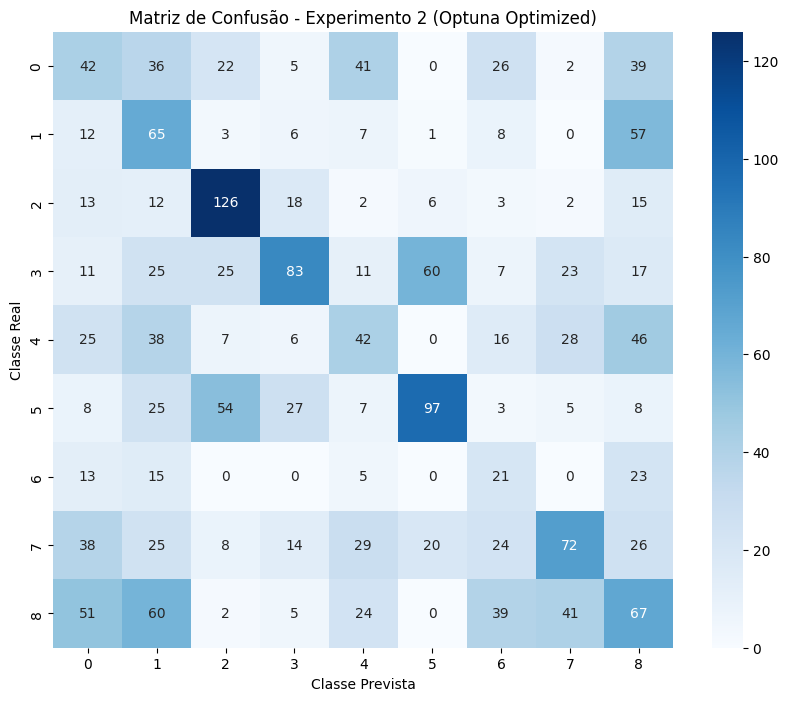

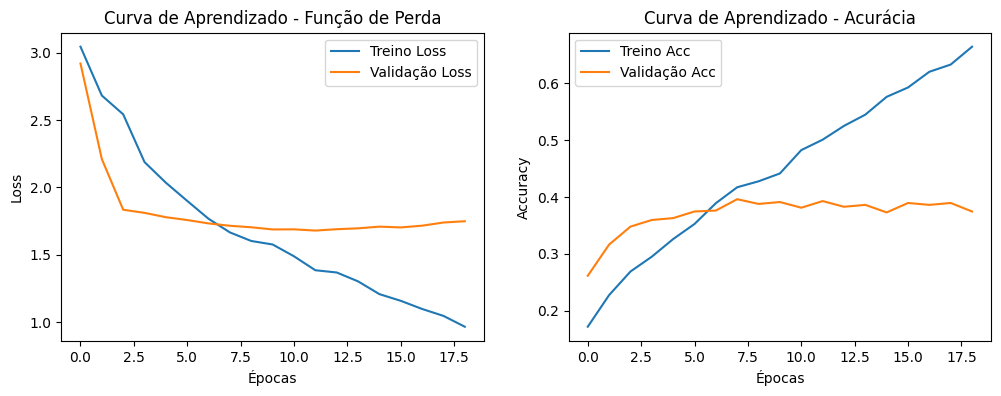

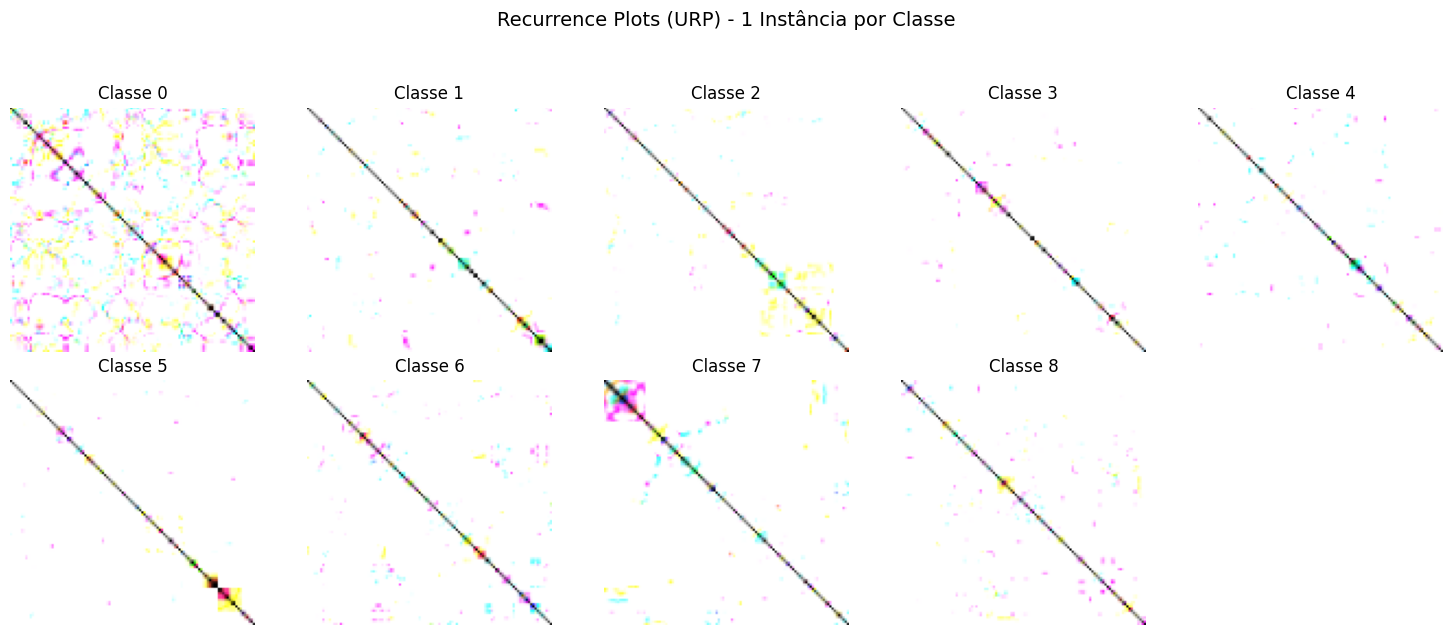

In [49]:
print("Construindo modelo definitivo do Experimento 2 com os melhores hiperparâmetros...")
model_exp2 = build_optuna_model(study.best_trial)

callbacks_exp2 = [
    callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    callbacks.ModelCheckpoint('modelo_exp2_optuna_best.keras', monitor='val_accuracy', save_best_only=True)
]

print("\nTreinando o Modelo Exp 2...")
history_exp2 = model_exp2.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=callbacks_exp2,
    class_weight=class_weights_dict
)

# Avaliação Exp 2
evaluate_experiment(model_exp2, history_exp2, test_generator, y_test, X_test_inercial, "Experimento 2 (Optuna Optimized)")